In [1]:
import os 
import sys

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)

In [2]:

import re

import math
import io
import torch
from torchvision import transforms
import numpy as np
import torch.nn as nn

from glob import glob

import FASCINATION.src.utils as utils 

from pathlib import Path

import hydra
from omegaconf import OmegaConf

from tqdm import tqdm

from PIL import Image

from scipy.ndimage import convolve


import matplotlib.pyplot as plt

from pytorch_msssim import ms_ssim

from FASCINATION.src.utils import loading_datamodule, unorm_ssp_arr_3D

from scipy.interpolate import interp1d

from scipy.signal import butter, filtfilt

import pickle 


In [3]:
from compressai.zoo import (bmshj2018_factorized, bmshj2018_hyperprior, mbt2018_mean, mbt2018, cheng2020_anchor)

In [4]:
from MLIC.MLIC.models import MLICPlusPlus #MLIC piped and added to external path
#from MLIC_copy.MLIC.models import MLICPlusPlus as RGB_MLICPlusPlus

In [5]:
from MLIC.MLIC.utils.utils import Config
#from MLIC.config.args import test_options

In [6]:
import scienceplots
plt.style.use('science')
#plt.style.use(['science','ieee'])
plt.rcParams.update({'figure.dpi': '100'}) #if IEEE and plt.show is used

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Functions

In [8]:
def float_to_rgb_image(arr):
    """
    Encode a 2D float32 array (in [0, 1]) into a 3-channel RGB uint8 image.
    """
    assert arr.ndim == 2, "Input must be 2D (H, W)"
    arr = np.clip(arr, 0, 1)
    val = (arr * (256**3 - 1)).astype(np.uint32)  # scale to [0, 16777215]

    r = (val >> 16) & 0xFF
    g = (val >> 8) & 0xFF
    b = val & 0xFF

    rgb = np.stack([r, g, b], axis=-1).astype(np.uint8)  # shape: (H, W, 3)
    return rgb

def save_float_array_as_png(arr, path):
    rgb_img = float_to_rgb_image(arr)
    img = Image.fromarray(rgb_img, mode="RGB")
    img.save(path)

In [9]:
def rgb_image_to_float(arr):
    """
    Decode a 3-channel RGB uint8 image (H, W, 3) back to float32 array in [0, 1].
    """
    r = arr[..., 0].astype(np.uint32)
    g = arr[..., 1].astype(np.uint32)
    b = arr[..., 2].astype(np.uint32)

    val = (r << 16) | (g << 8) | b
    return val.astype(np.float32) / (256**3 - 1)

def load_float_array_from_png(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img)
    return rgb_image_to_float(arr)

In [10]:
def rgb_image_to_float_tensor(tensor):
    """
    Decode a 3-channel RGB float32 tensor (C, H, W) in [0, 1] back to a float32 array in [0, 1].
    """
    assert tensor.ndim == 3 and tensor.size(0) == 3, "Input must be a 3-channel tensor (C, H, W)"
    
    # Scale tensor to uint32 range
    tensor = (tensor * (256**3 - 1)).to(torch.uint32)
    
    # Extract RGB channels
    r = (tensor[0] << 16)
    g = (tensor[1] << 8)
    b = tensor[2]
    
    # Combine channels and normalize
    val = r + g + b
    return val.to(torch.float32) / (256**3 - 1)

In [11]:
def get_min_max_idx(arr,axs=1, pad=True):
    grad = np.diff(arr,axis=axs)
    grad_sign = np.sign(grad)
    min_max = np.diff(grad_sign,axis=axs) 
    min_max = np.abs(np.sign(min_max))
    if pad:
        min_max = np.pad(min_max, ((0,0),(1,1),(0,0),(0,0)), 'constant', constant_values=1)
    return min_max


In [12]:
def cubic_interpolate_along_axis(arr: np.ndarray, target_size: int, axis: int) -> np.ndarray:
    """
    Interpolates a NumPy array along a specified axis using cubic splines.

    Parameters:
        arr (np.ndarray): Input array of arbitrary shape.
        target_size (int): Desired size along the interpolation axis.
        axis (int): Axis to interpolate along.

    Returns:
        np.ndarray: Interpolated array with the same shape except along `axis`.
    """
    original_shape = arr.shape
    current_size = arr.shape[axis]

    # Generate old and new coordinate grids normalized to [0, 1]
    x_old = np.linspace(0, 1, current_size)
    x_new = np.linspace(0, 1, target_size)

    # Move the axis to interpolate to the front for easier broadcasting
    arr_swapped = np.moveaxis(arr, axis, 0)  # Shape: (current_size, ...)
    reshaped = arr_swapped.reshape(current_size, -1)  # Shape: (current_size, -1)

    # Perform interpolation
    f = interp1d(x_old, reshaped, kind='cubic', axis=0, bounds_error=False, fill_value="extrapolate")
    interpolated = f(x_new)  # Shape: (target_size, -1)

    # Reshape back and move axis to original position
    new_shape = (target_size,) + arr_swapped.shape[1:]
    interpolated = interpolated.reshape(new_shape)
    return np.moveaxis(interpolated, 0, axis)

In [13]:
def get_f1_score(min_max_idx_truth, min_max_idx_ae, axs=1, kernel_size=10):



    # Define the kernel based on the shape of the truth array
    kernel_shape = [1] * min_max_idx_truth.ndim
    kernel_shape[axs] = kernel_size  # Set the size of the kernel along the specified axis
    kernel = np.ones(kernel_shape)

    # Expand the truth array with the kernel
    truth_expanded = convolve(min_max_idx_truth, kernel, mode='constant', cval=0.0)
    ae_expanded = convolve(min_max_idx_ae, kernel, mode='constant', cval=0.0)

    # Compute the true positives
    true_positives = (truth_expanded > 0) & (min_max_idx_ae > 0)
    num_true_positives = np.sum(true_positives, axis=axs)

    # Compute the false positives
    false_positives = (truth_expanded == 0) & (min_max_idx_ae > 0)
    num_false_positives = np.sum(false_positives, axis=axs)

    # Compute the false negatives
    false_negatives = (min_max_idx_truth > 0) & (ae_expanded == 0)
    num_false_negatives = np.sum(false_negatives, axis=axs)

    # Compute precision and recall while avoiding division by zero
    precision_den = num_true_positives + num_false_positives
    recall_den = num_true_positives + num_false_negatives

    precision_score = np.where(precision_den == 0, 0, num_true_positives / precision_den)
    recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)

    # Compute f1_score and avoid division by zero when both precision and recall are 0
    sum_scores = precision_score + recall_score
    f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)

    return f1_score

In [14]:
def compute_psnr(a, b):
    mse = np.mean((a - b) ** 2)
    return -10 * np.log10(mse)

In [15]:

def compute_msssim(a, b):
    return ms_ssim(a, b, data_range=1.).item()

In [16]:

def compute_bpp(out_net):
    size = out_net['x_hat'].size()
    num_pixels = size[0] * size[2] * size[3]
    return sum(torch.log(likelihoods).sum() / (-math.log(2) * num_pixels)
              for likelihoods in out_net['likelihoods'].values()).item()

def compute_total_bits(out_net):
    return sum(torch.log(likelihoods).sum() / (-math.log(2))
              for likelihoods in out_net['likelihoods'].values()).item()

def compute_bits_per_sample(out_net):
    num_sample = out_net['x_hat'].size(0)
    return sum(torch.log(likelihoods).sum() / (-math.log(2)*num_sample)
              for likelihoods in out_net['likelihoods'].values()).item()

def compute_bits_per_elements(out_net):
    size = out_net['x_hat'].numel()
    return sum(torch.log(likelihoods).sum() / (-math.log(2) * size)
              for likelihoods in out_net['likelihoods'].values()).item()


def compute_compression_rate(out_net, bits_per_channel=8):
    original_bits = out_net['x_hat'].numel() * bits_per_channel
    compressed_bits = sum(
        -torch.log(likelihoods).sum() / math.log(2)
        for likelihoods in out_net['likelihoods'].values()
    ).item()
    return original_bits / compressed_bits

In [17]:


def parse_experiment_config(model_path):
    """
    Parse experiment_config.log file to extract N and M values.
    
    Args:
        model_path (str): Path to the model directory containing experiment_config.log
        
    Returns:
        tuple: (N, M) values or (None, None) if parsing fails
    """
    
    config_file = list(Path(model_path).rglob("train_*.log"))    
    if config_file==[]:
        print(f"Warning: train logs not found in {model_path}")
        return None, None
    
    config_file = config_file[0]  # Get the first match if multiple found

    try:
        with open(config_file, 'r') as f:
            content = f.read()
        
        # Extract N and M values from MODEL CONFIGURATION section
        N, M = None, None
        
        lines = content.split('\n')

        cfg = eval((lines[1].strip().split("INFO: ")[-1]).replace("<class 'torch.nn.modules.activation.","nn.").replace("'>",""))


        return cfg
        
        # N = cfg['N']
        # M = cfg['M']

    #     if N is not None and M is not None:
    #         print(f"Extracted from {model_path}: N={N}, M={M}")
    #         return N, M
    #     else:
    #         print(f"Warning: Could not extract N and M from {model_path}")
    #         return None, None
            
    except Exception as e:
        print(f"Error parsing config file in {model_path}: {e}")
        return None




In [18]:


def reorder_rowwise(flat_list, ncol):
    return sum((flat_list[i::ncol] for i in range(ncol)), [])

def custom_label_sort(label):
    if label == "PCA":
        return (0, 0)
    elif label.startswith("PCA pooled by factor "):
        # Extract the pooling factor (e.g., 2, 4, 8, 16)
        factor = int(label.split("factor ")[1].split("x")[0])
        return (1, factor)
    elif label == "rgb mlic++":
        return (2, 0)
    elif label == "ssp mlic++":
        return (3, 0)
    else:
        return (99, label)  # fallback for unknown labels



# Load data

In [19]:
pca_file = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_pca_all_components_with_pooling_upsampling_unorm_xp_autoencoder_V2_dif_pca_V2.pkl"

with open(pca_file, "rb") as file:
    pca_rmse_dict = pickle.load(file)  




In [20]:
import pandas as pd

# Load the CSV file into a DataFrame
space_depth_pca_metrics_df = pd.read_csv("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/space_depth_pca_metrics.csv")

# Display the first few rows
space_depth_pca_metrics_df.head() 

,Unnamed: 0,CR,RMSE,PSNR,MS-SSIM,ECS,MAE,mean_error_n_min_max,F1_score,R2_score
0,0.50,1.055040e+06,4.396561,-12.862261,0.642869,187.867688,2.949677,1.377386,0.372025,0.920669
1,0.80,3.768000e+05,3.416507,-10.671645,0.655022,118.514924,2.183834,1.597320,0.409203,0.952095
2,0.90,1.648500e+05,2.803282,-8.953337,0.724499,116.177054,1.854916,1.554976,0.434059,0.967749
3,0.95,9.420000e+04,2.398217,-7.597771,0.769397,113.526535,1.624954,1.522568,0.453118,0.976396
4,0.98,2.791111e+04,1.582107,-3.984718,0.848602,96.631155,1.061865,1.478810,0.527206,0.989727


In [21]:
season_csv = {"all": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_all_pca_metrics.csv",
              "summer": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_summer_pca_metrics.csv",
              "winter": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_winter_pca_metrics.csv",
              "spring": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_spring_pca_metrics.csv",
              "autumn": "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_autumn_pca_metrics.csv"}  

season_dfs = {season: pd.read_csv(path) for season, path in season_csv.items()}

In [22]:
all_pca_metrics_df = pd.read_csv("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics_all_pca_metrics.csv")

# Display the first few rows
all_pca_metrics_df

,Unnamed: 0,CR,RMSE,PSNR,MS-SSIM,ECS,MAE,mean_error_n_min_max,F1_score,R2_score,n_depth,m_spatial,k_time
0,0.50,2.543400e+06,5.983541,-15.539166,0.485674,199.915158,4.009138,1.208625,0.342007,0.852132,1,4,2
1,0.80,7.266857e+05,5.737482,-15.174427,0.492774,200.203480,3.852917,1.255221,0.350792,0.864043,1,13,7
2,0.90,5.652000e+05,4.995463,-13.971515,0.507419,155.189241,3.216626,1.451550,0.355821,0.896935,2,15,9
3,0.95,2.826000e+05,4.778045,-13.585005,0.520836,150.736666,3.101029,1.447956,0.368754,0.905711,2,29,18
4,0.98,1.374811e+05,4.484714,-13.034694,0.538476,131.865364,2.919984,1.436303,0.384950,0.916933,3,67,37


In [23]:
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_3_depth.pkl", "rb") as f:
    model_metrics = pickle.load(f)


In [24]:
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/season_metrics_all_pca.pkl", "rb") as f:
    pca_all_metrics = pickle.load(f)

# Load models

In [25]:
# data_path ={"enatl": "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc",
#             "natl": "/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_sound_speed_regrid_0_botm.nc"}

In [26]:
try:
    if dm_dict:
        print("Not reloading datamodule")

except:
    
    dm_dict = {}
    
    n_components = 0
    print("Initializing datamodule")

Initializing datamodule


In [27]:
# xp="autoencoder_V2"
# cfg_path = f"/Odyssey/private/o23gauvr/code/FASCINATION/config/xp/{xp}.yaml"
# cfg = OmegaConf.load(cfg_path)

In [28]:
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_4_157_196_256.pkl", "rb") as f_rgb:
    dm_mlic = pickle.load(f_rgb)

In [29]:
depth_array = dm_mlic.depth_array
test_ssp_arr = dm_mlic.test_da.data

In [30]:
metric = 'mse'  # only pre-trained model for mse are available for now
quality = 5     # lower quality -> lower bit-rate (use lower quality to clearly see visual differences in the notebook)

In [31]:
mlic_config_ssp = Config({
    "N": 249,
    "M": 320,
    "slice_num": 10,
    "context_window": 5,
    "act": nn.GELU,
    "in_channels": 157, 
    "out_channels": 157 # e.g., 3 for RGB, 157 for your current data
})

mlic_config_rgb = Config({
    "N": 192,
    "M": 320,
    "slice_num": 10,
    "context_window": 5,
    "act": nn.GELU,
    "in_channels": 3, 
    "out_channels": 3 # e.g., 3 for RGB, 157 for your current data
})

In [32]:
# mlic_args = test_options()
# mlic_args

In [33]:
# networks = {
#     'bmshj2018-factorized': bmshj2018_factorized(quality=quality, pretrained=True).eval().to(device), #'bmshj2018-hyperprior': bmshj2018_hyperprior(quality=quality, pretrained=True).eval().to(device),
#     'mbt2018-mean': mbt2018_mean(quality=quality, pretrained=True).eval().to(device), #    'mbt2018': mbt2018(quality=quality, pretrained=True).eval().to(device),
#     'cheng2020-anchor': cheng2020_anchor(quality=quality, pretrained=True).eval().to(device),
#     'mlic++': mlic_net
# }

# Reconstruct from dm

In [34]:
mlic_ckpt_dict = {}

base_dir = "/Odyssey/private/o23gauvr/code/MLIC/experiments/keep"


# List the first-level directories in the base directory
first_level_dirs = next(os.walk(base_dir))[1]

# Iterate through the first-level directories
for dir_name in first_level_dirs:
    if dir_name == "mute":
        continue
    # Create the relative path
    relative_path = os.path.join(base_dir, dir_name)
    # Add to the dictionary
    mlic_ckpt_dict[dir_name] = relative_path

# Print the dictionary
print(mlic_ckpt_dict)


for model_carac in mlic_ckpt_dict.keys():

    ckpt_list =  list(Path(mlic_ckpt_dict[model_carac]).rglob('checkpoint_best_loss.pth.tar'))
    print(f"Model {model_carac} with {len(ckpt_list)} checkpoints")


{'mlicpp_on_ssp_192_320_lambda0.0018_min_max': '/Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_lambda0.0018_min_max', 'mlicpp_on_ssp_192_320_0.0483_min_max': '/Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_0.0483_min_max', 'mlicpp_on_ssp_640_960_0.0483_min_max': '/Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_640_960_0.0483_min_max', 'mlicpp_on_ssp_640_960_0.0018_min_max': '/Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_640_960_0.0018_min_max', 'mlicpp_on_ssp_192_320_0.025_min_max': '/Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_0.025_min_max', 'mlicpp_on_ssp_128_192_0.025_min_max': '/Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_128_192_0.025_min_max', 'mlicpp_on_ssp_640_960_0.025_min_max': '/Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_640_960_0.025_min_max', 'mlicpp_on_rgb_192_320_0.025_min_max': '/Odyssey/private/o23ga

In [35]:
for model_name, model_path in tqdm(mlic_ckpt_dict.items(), desc="SSP MLIC++ models"):
    # Find the best checkpoint
    ckpt_files = list(Path(model_path).rglob('checkpoint_best_loss.pth.tar'))
    if not ckpt_files:
        print(f"No checkpoint found for {model_name}")
        continue
    
    ckpt_file = ckpt_files[0]
    print(f"\nLoading {model_name} from {ckpt_file}")
    
    # Automatically extract N and M from experiment_config.log
    cfg = parse_experiment_config(model_path)

SSP MLIC++ models:   9%|▉         | 1/11 [00:00<00:01,  8.86it/s]


Loading mlicpp_on_ssp_192_320_lambda0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_lambda0.0018_min_max/checkpoints/checkpoint_best_loss.pth.tar

Loading mlicpp_on_ssp_192_320_0.0483_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_0.0483_min_max/checkpoints/checkpoint_best_loss.pth.tar


SSP MLIC++ models:  18%|█▊        | 2/11 [00:00<00:01,  8.63it/s]


Loading mlicpp_on_ssp_640_960_0.0483_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_640_960_0.0483_min_max/checkpoints/checkpoint_best_loss.pth.tar

Loading mlicpp_on_ssp_640_960_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_640_960_0.0018_min_max/checkpoints/checkpoint_best_loss.pth.tar

Loading mlicpp_on_ssp_192_320_0.025_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_0.025_min_max/20250820_183409/checkpoints/checkpoint_best_loss.pth.tar


SSP MLIC++ models:  64%|██████▎   | 7/11 [00:00<00:00, 12.46it/s]


Loading mlicpp_on_ssp_128_192_0.025_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_128_192_0.025_min_max/checkpoints/checkpoint_best_loss.pth.tar

Loading mlicpp_on_ssp_640_960_0.025_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_640_960_0.025_min_max/1948_epochs/checkpoints/checkpoint_best_loss.pth.tar

Loading mlicpp_on_rgb_192_320_0.025_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_rgb_192_320_0.025_min_max/ckpt_20250821_164209/checkpoints/checkpoint_best_loss.pth.tar

Loading mlicpp_on_ssp_1600_2400_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_1600_2400_0.0018_min_max/20250825_175640/checkpoints/checkpoint_best_loss.pth.tar

Loading mlicpp_on_ssp_16_32_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_16_32_0.0018_min_max/20250825_174451/checkpoints/checkpoint_best_loss.pth.tar


SSP MLIC++ models: 100%|██████████| 11/11 [00:00<00:00, 11.63it/s]


Loading mlicpp_on_ssp_64_96_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_64_96_0.0018_min_max/20250825_174247/checkpoints/checkpoint_best_loss.pth.tar


In [36]:


selected_models = ['mlic++'] #'mbt2018-mean'  #'cheng2020-anchor','bmshj2018-factorized','mlic++'  # Add others like 'bmshj2018-factorized', etc.


In [37]:
unified_name = False
    
# Initialize containers
bit_rates = {}
outputs = {}

if unified_name:
    # Initialize the unified "ssp mlic++" entry
    model_name = "ssp mlic++"
    bit_rates[model_name] = {}
    outputs[model_name] = {}

# First, process SSP MLIC++ models separately
print("===== Processing SSP MLIC++ models =====")
for model_name, model_path in tqdm(mlic_ckpt_dict.items(), desc="SSP MLIC++ models"):
    # Find the best checkpoint
    ckpt_files = list(Path(model_path).rglob('checkpoint_best_loss.pth.tar'))
    if not ckpt_files:
        print(f"No checkpoint found for {model_name}")
        continue
    
    for ckpt_file in ckpt_files:

        print(f"\nLoading {model_name} from {ckpt_file}")
        
        # Automatically extract N and M from experiment_config.log
        cfg = parse_experiment_config(model_path)

        N = cfg.get('N', 192)
        M = cfg.get('M', 320)

        if cfg.get("in_channels",None) != 157:
            print("Skipping RGB models")
            continue

        # if N is None or M is None:
        #     print(f"Could not extract N and M for {model_name}, set to default values 192,320.")
        #     N,M = 192,320
        #     #continue
        
        # Create config for this model
        ssp_config = Config({
            "N": N,
            "M": M,
            "slice_num": cfg.get('slice_num', 10),
            "context_window": cfg.get('context_window', 5),
            "act": cfg.get('act', nn.GELU),
            "in_channels": 157,
            "out_channels": 157
        })
        
        # Load the model
        try:
            ssp_mlic_net = MLICPlusPlus(config=ssp_config).eval().to(device)
            checkpoint = torch.load(ckpt_file, map_location=device, weights_only=False)
            ssp_mlic_net.load_state_dict(checkpoint['state_dict'])
            
            # Process the data
            x = torch.tensor(test_ssp_arr.copy()).to(device)
            
            with torch.no_grad():
                rv = ssp_mlic_net(x)
            
            # Compute metrics
            bits = compute_total_bits(rv)
            numel = rv['x_hat'].numel()
            original_bits = numel * 8
            
            bpe = bits / numel
            cr = original_bits / bits
            

            if unified_name:
                # Initialize the unified "ssp mlic++" entry
                model_name = "ssp mlic++"
            else:
                if len(ckpt_files)>1:
                    sub_name = "_" + (str(ckpt_file).split(f'{model_name}/')[-1]).split('/')[0]
                else:
                    sub_name = ""
                dict_model_name = (model_name.split("mlicpp_on_ssp_")[-1]).split("_min_max")[0] + sub_name

                bit_rates[dict_model_name] = {}
                outputs[dict_model_name] = {}
                
            # Store under unified name with different CR values
            bit_rates[dict_model_name][cr] = {
                "bits_per_element": bpe,
                "compression_rate": cr,
                "total_compressed_bits": bits,
                "total_original_bits": original_bits,
                "model_config": f"N={N}, M={M}",  # Store config info for reference
                "original_model_name": model_name  # Store original name for reference
            }
            
            reconstructed_arr = rv['x_hat'].detach().cpu().numpy()
            unorm_reconstructed_arr = unorm_ssp_arr_3D(reconstructed_arr, dm_mlic)
            outputs[dict_model_name][cr] = unorm_reconstructed_arr
            
            print(f"  Model config: N={N}, M={M}")
            print(f"  Compression rate: {cr:.2f}x, Bits per element: {bpe:.4f}")
            print(f"  Stored as '{dict_model_name}' with CR {cr:.2f}x")
            
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue

===== Processing SSP MLIC++ models =====


SSP MLIC++ models:   0%|          | 0/11 [00:00<?, ?it/s]


Loading mlicpp_on_ssp_192_320_lambda0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_lambda0.0018_min_max/checkpoints/checkpoint_best_loss.pth.tar


/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538435607/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
SSP MLIC++ models:   9%|▉         | 1/11 [00:20<03:20, 20.02s/it]

  Model config: N=192, M=320
  Compression rate: 167098.03x, Bits per element: 0.0000
  Stored as '192_320_lambda0.0018' with CR 167098.03x

Loading mlicpp_on_ssp_192_320_0.0483_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_0.0483_min_max/checkpoints/checkpoint_best_loss.pth.tar


...

  Model config: N=1600, M=2400
  Compression rate: 216.11x, Bits per element: 0.0370
  Stored as '1600_2400_0.0018' with CR 216.11x

Loading mlicpp_on_ssp_16_32_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_16_32_0.0018_min_max/20250825_174451/checkpoints/checkpoint_best_loss.pth.tar


SSP MLIC++ models:  91%|█████████ | 10/11 [10:45<01:29, 89.71s/it]

  Model config: N=16, M=32
  Compression rate: 365285.55x, Bits per element: 0.0000
  Stored as '16_32_0.0018' with CR 365285.55x

Loading mlicpp_on_ssp_64_96_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_64_96_0.0018_min_max/20250825_174247/checkpoints/checkpoint_best_loss.pth.tar


SSP MLIC++ models: 100%|██████████| 11/11 [10:49<00:00, 59.01s/it]

  Model config: N=64, M=96
  Compression rate: 360107.66x, Bits per element: 0.0000
  Stored as '64_96_0.0018' with CR 360107.66x


In [38]:

# # Load RGB MLIC++ checkpoint
# print("===== Loading RGB MLIC++ =====")
# mlic_config_rgb = Config({
#     "N": 192,
#     "M": 320,
#     "slice_num": 10,
#     "context_window": 5,
#     "act": nn.GELU,
#     "in_channels": 3, 
#     "out_channels": 3
# })

# rgb_mlic_net = MLICPlusPlus(config=mlic_config_rgb).eval().to(device)
# rgb_mlic_checkpoint = torch.load("/Odyssey/private/o23gauvr/code/MLIC/checkpoints/renamed_mlicpp_mse_q5_2960000.pth.tar", 
#                                 map_location=device, weights_only=True)
# rgb_state_dict = rgb_mlic_checkpoint['state_dict']
# print(f"RGB MLIC++ loaded with {len(rgb_state_dict)} layers")

# # Get SSP MLIC++ checkpoint paths
# mlic_ckpt_dict = {}
# base_dir = "/Odyssey/private/o23gauvr/code/MLIC/experiments"
# first_level_dirs = next(os.walk(base_dir))[1]

# for dir_name in first_level_dirs:
#     if dir_name != "mute":
#         relative_path = os.path.join(base_dir, dir_name)
#         mlic_ckpt_dict[dir_name] = relative_path

# print(f"Found {len(mlic_ckpt_dict)} SSP MLIC++ experiment directories")

# # Compare with each SSP MLIC++ checkpoint
# print("\n===== Comparing SSP MLIC++ checkpoints with RGB MLIC++ =====")
# for model_name, model_path in tqdm(mlic_ckpt_dict.items(), desc="SSP MLIC++ models"):
#     # Find the best checkpoint
#     ckpt_files = list(Path(model_path).rglob('checkpoint_best_loss.pth.tar'))
#     if not ckpt_files:
#         print(f"No checkpoint found for {model_name}")
#         continue
    
#     ckpt_file = ckpt_files[0]
#     print(f"\n{'='*60}")
#     print(f"Comparing: {model_name}")
#     print(f"Checkpoint: {ckpt_file}")
    
#     # Extract N and M from experiment config
#     N, M = parse_experiment_config(model_path)
    
#     if N is None or M is None:
#         print(f"Could not extract N and M for {model_name}, using defaults 192,320")
#         N, M = 192, 320
    
#     # Create config for SSP model
#     ssp_config = Config({
#         "N": N,
#         "M": M,
#         "slice_num": 10,
#         "context_window": 5,
#         "act": nn.GELU,
#         "in_channels": 157, 
#         "out_channels": 157
#     })
    
#     # Load SSP checkpoint
#     try:
#         checkpoint = torch.load(ckpt_file, map_location=device, weights_only=False)
#         ssp_state_dict = checkpoint['state_dict']
        
#         print(f"SSP Model config: N={N}, M={M}, in_channels=157")
#         print(f"RGB Model config: N=192, M=320, in_channels=3")
#         print(f"SSP state_dict has {len(ssp_state_dict)} layers")
        
#         # Compare layer shapes
#         shape_differences = []
        
#         print(f"\n{'Layer Name':<50} {'RGB Shape':<20} {'SSP Shape':<20} {'Match'}")
#         print("-" * 100)
        
#         # Get all unique layer names
#         all_layers = set(rgb_state_dict.keys()) | set(ssp_state_dict.keys())
        
#         for layer_name in sorted(all_layers):
#             rgb_shape = rgb_state_dict.get(layer_name, None)
#             ssp_shape = ssp_state_dict.get(layer_name, None)
            
#             rgb_shape_str = str(tuple(rgb_shape.shape)) if rgb_shape is not None else "Missing"
#             ssp_shape_str = str(tuple(ssp_shape.shape)) if ssp_shape is not None else "Missing"
            
#             if rgb_shape is not None and ssp_shape is not None:
#                 shapes_match = rgb_shape.shape == ssp_shape.shape
#                 match_str = "✓" if shapes_match else "✗"
                
#                 if not shapes_match:
#                     shape_differences.append({
#                         'layer': layer_name,
#                         'rgb_shape': rgb_shape.shape,
#                         'ssp_shape': ssp_shape.shape
#                     })
#             else:
#                 match_str = "Missing"
#                 shape_differences.append({
#                     'layer': layer_name,
#                     'rgb_shape': rgb_shape_str,
#                     'ssp_shape': ssp_shape_str
#                 })
            
#             print(f"{layer_name:<50} {rgb_shape_str:<20} {ssp_shape_str:<20} {match_str}")
        
#         # Summary of differences
#         print(f"\n📊 SUMMARY for {model_name}:")
#         print(f"   Total layers compared: {len(all_layers)}")
#         print(f"   Layers with different shapes: {len(shape_differences)}")
        
#         if shape_differences:
#             print(f"\n🔍 SHAPE DIFFERENCES:")
#             for diff in shape_differences:
#                 print(f"   • {diff['layer']}")
#                 print(f"     RGB: {diff['rgb_shape']}")
#                 print(f"     SSP: {diff['ssp_shape']}")
#         else:
#             print("   ✅ All layer shapes match!")
            
#     except Exception as e:
#         print(f"❌ Error loading {model_name}: {e}")
#         continue

#     break

# print(f"\n{'='*60}")
# print("Comparison complete!")

In [39]:
# import torch
# import os

# def rename_rgb_checkpoint_layers():
#     """
#     Rename RGB MLIC++ checkpoint layers to match SSP naming convention
#     """
    
#     # Load the RGB checkpoint
#     rgb_checkpoint_path = "/Odyssey/private/o23gauvr/code/MLIC/checkpoints/mlicpp_mse_q5_2960000.pth.tar"
#     print(f"Loading RGB checkpoint from: {rgb_checkpoint_path}")
    
#     rgb_checkpoint = torch.load(rgb_checkpoint_path, map_location='cpu', weights_only=False)
#     rgb_state_dict = rgb_checkpoint['state_dict']
    
#     print(f"Original state_dict has {len(rgb_state_dict)} layers")
    
#     # Create a new state_dict with renamed layers
#     new_state_dict = {}
    
#     # Define the mapping from old names to new names
#     layer_mappings = {
#         # Bias mappings
#         'entropy_bottleneck._bias0': 'entropy_bottleneck.biases.0',
#         'entropy_bottleneck._bias1': 'entropy_bottleneck.biases.1', 
#         'entropy_bottleneck._bias2': 'entropy_bottleneck.biases.2',
#         'entropy_bottleneck._bias3': 'entropy_bottleneck.biases.3',
#         'entropy_bottleneck._bias4': 'entropy_bottleneck.biases.4',
        
#         # Factor mappings
#         'entropy_bottleneck._factor0': 'entropy_bottleneck.factors.0',
#         'entropy_bottleneck._factor1': 'entropy_bottleneck.factors.1',
#         'entropy_bottleneck._factor2': 'entropy_bottleneck.factors.2', 
#         'entropy_bottleneck._factor3': 'entropy_bottleneck.factors.3',
        
#         # Matrix mappings
#         'entropy_bottleneck._matrix0': 'entropy_bottleneck.matrices.0',
#         'entropy_bottleneck._matrix1': 'entropy_bottleneck.matrices.1',
#         'entropy_bottleneck._matrix2': 'entropy_bottleneck.matrices.2',
#         'entropy_bottleneck._matrix3': 'entropy_bottleneck.matrices.3',
#         'entropy_bottleneck._matrix4': 'entropy_bottleneck.matrices.4'
#     }
    
#     # Copy all layers, renaming the ones that need it
#     renamed_count = 0
#     for old_name, tensor in rgb_state_dict.items():
#         if old_name in layer_mappings:
#             new_name = layer_mappings[old_name]
#             new_state_dict[new_name] = tensor
#             print(f"Renamed: {old_name} -> {new_name}")
#             renamed_count += 1
#         else:
#             # Keep the original name for layers that don't need renaming
#             new_state_dict[old_name] = tensor
    
#     print(f"\nRenamed {renamed_count} layers")
#     print(f"New state_dict has {len(new_state_dict)} layers")
    
#     # Update the checkpoint with the new state_dict
#     rgb_checkpoint['state_dict'] = new_state_dict
    
#     # Save the renamed checkpoint
#     output_path = "/Odyssey/private/o23gauvr/code/MLIC/checkpoints/renamed_mlicpp_mse_q5_2960000.pth.tar"
#     print(f"\nSaving renamed checkpoint to: {output_path}")
    
#     torch.save(rgb_checkpoint, output_path)
#     print("✅ Successfully saved renamed checkpoint!")
    
#     # Verify the renaming worked
#     print("\n🔍 Verification:")
#     renamed_checkpoint = torch.load(output_path, map_location='cpu', weights_only=False)
#     renamed_state_dict = renamed_checkpoint['state_dict']
    
#     print(f"Renamed checkpoint has {len(renamed_state_dict)} layers")
    
#     # Check if the renamed layers exist
#     expected_new_names = list(layer_mappings.values())
#     found_new_names = [name for name in expected_new_names if name in renamed_state_dict]
    
#     print(f"Found {len(found_new_names)}/{len(expected_new_names)} expected renamed layers")
    
#     # Check if old names are gone
#     old_names = list(layer_mappings.keys())
#     remaining_old_names = [name for name in old_names if name in renamed_state_dict]
    
#     if remaining_old_names:
#         print(f"⚠️  Warning: {len(remaining_old_names)} old names still present: {remaining_old_names}")
#     else:
#         print("✅ All old layer names successfully removed")
        
#     return output_path

# # Run the renaming
# if __name__ == "__main__":
#     renamed_checkpoint_path = rename_rgb_checkpoint_layers()
#     print(f"\nRenamed checkpoint saved at: {renamed_checkpoint_path}")

In [40]:


if unified_name:
    # Initialize the unified "rgb mlic++" entry
    model_name = "rgb mlic++"


# First, process RGB MLIC++ models separately
print("===== Processing RGB MLIC++ models =====")
for model_name, model_path in tqdm(mlic_ckpt_dict.items(), desc="RGB MLIC++ models"):
    # Find the best checkpoint
    ckpt_files = list(Path(model_path).rglob('checkpoint_best_loss.pth.tar'))
    if not ckpt_files:
        print(f"No checkpoint found for {model_name}")
        continue
    
    for ckpt_file in ckpt_files:

        print(f"\nLoading {model_name} from {ckpt_file}")
        
        # Automatically extract N and M from experiment_config.log
        cfg = parse_experiment_config(model_path)

        N = cfg.get('N', 192)
        M = cfg.get('M', 320)

        if cfg.get("in_channels",None) != 3:
            print("Skipping SSP models")
            continue

        # if N is None or M is None:
        #     print(f"Could not extract N and M for {model_name}, set to default values 192,320.")
        #     N,M = 192,320
        #     #continue
        
        # Create config for this model
        ssp_config = Config({
            "N": N,
            "M": M,
            "slice_num": cfg.get('slice_num', 10),
            "context_window": cfg.get('context_window', 5),
            "act": cfg.get('act', nn.GELU),
            "in_channels": 3,
            "out_channels": 3
        })
        
        # Load the model
        try:
            rgb_mlic_net = MLICPlusPlus(config=ssp_config).eval().to(device)
            checkpoint = torch.load(ckpt_file, map_location=device, weights_only=False)
            rgb_mlic_net.load_state_dict(checkpoint['state_dict'])

            reconstructed_arr = np.zeros(test_ssp_arr.shape)
            total_bits = 0
            total_elements = 0
            total_original_bits = 0

            # Process RGB models by splitting into 3-channel chunks
            n_imgs = len(depth_array) // 3

            for j in range(n_imgs):
                start_idx = j * 3   
                end_idx = start_idx + 3

                x = torch.tensor(test_ssp_arr[:, start_idx:end_idx, :, :].copy()).to(device)

                with torch.no_grad():
                    rv = rgb_mlic_net(x)

                bits = compute_total_bits(rv)
                numel = rv['x_hat'].numel()
                original_bits = numel * 8

                total_bits += bits
                total_elements += numel
                total_original_bits += original_bits

                reconstructed_arr[:, start_idx:end_idx] = rv['x_hat'].detach().cpu().numpy()

            bpe = total_bits / total_elements
            cr = total_original_bits / total_bits



            if unified_name:
                # Initialize the unified "ssp mlic++" entry
                dict_model_name = "rgb mlic++"
            else:
                if len(ckpt_files)>1:
                    sub_name = "_" + (str(ckpt_file).split(f'{model_name}/')[-1]).split('/')[0]
                else:
                    sub_name = ""
                dict_model_name = model_name.split("_min_max")[0] + sub_name

                bit_rates[dict_model_name] = {}
                outputs[dict_model_name] = {}

                # Store under unified name with different CR values
                bit_rates[dict_model_name][cr] = {
                    "bits_per_element": bpe,
                    "compression_rate": cr,
                    "total_compressed_bits": bits,
                    "total_original_bits": original_bits,
                    "model_config": f"N={N}, M={M}",  # Store config info for reference
                    "original_model_name": model_name  # Store original name for reference
                }
                
                #reconstructed_arr = rv['x_hat'].detach().cpu().numpy()
                unorm_reconstructed_arr = unorm_ssp_arr_3D(reconstructed_arr, dm_mlic)
                outputs[dict_model_name][cr] = unorm_reconstructed_arr
                
                print(f"  Model config: N={N}, M={M}")
                print(f"  Compression rate: {cr:.2f}x, Bits per element: {bpe:.4f}")
                print(f"  Stored as '{dict_model_name}' with CR {cr:.2f}x")

        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue     


===== Processing RGB MLIC++ models =====


RGB MLIC++ models:   0%|          | 0/11 [00:00<?, ?it/s]


Loading mlicpp_on_ssp_192_320_lambda0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_lambda0.0018_min_max/checkpoints/checkpoint_best_loss.pth.tar
Skipping SSP models

Loading mlicpp_on_ssp_192_320_0.0483_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_0.0483_min_max/checkpoints/checkpoint_best_loss.pth.tar
Skipping SSP models

Loading mlicpp_on_ssp_640_960_0.0483_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_640_960_0.0483_min_max/checkpoints/checkpoint_best_loss.pth.tar
Skipping SSP models

Loading mlicpp_on_ssp_640_960_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_640_960_0.0018_min_max/checkpoints/checkpoint_best_loss.pth.tar
Skipping SSP models

Loading mlicpp_on_ssp_192_320_0.025_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_192_320_0.025_min_max/20250820_183409/checkpoints/checkpoint_be

RGB MLIC++ models: 100%|██████████| 11/11 [00:37<00:00,  3.38s/it]

  Model config: N=192, M=320
  Compression rate: 6320.99x, Bits per element: 0.0013
  Stored as 'mlicpp_on_rgb_192_320_0.025_no_ckpt_20250821_162645' with CR 6320.99x

Loading mlicpp_on_ssp_1600_2400_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_1600_2400_0.0018_min_max/20250825_175640/checkpoints/checkpoint_best_loss.pth.tar
Skipping SSP models

Loading mlicpp_on_ssp_16_32_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_16_32_0.0018_min_max/20250825_174451/checkpoints/checkpoint_best_loss.pth.tar
Skipping SSP models

Loading mlicpp_on_ssp_64_96_0.0018_min_max from /Odyssey/private/o23gauvr/code/MLIC/experiments/keep/mlicpp_on_ssp_64_96_0.0018_min_max/20250825_174247/checkpoints/checkpoint_best_loss.pth.tar
Skipping SSP models


In [41]:
outputs.keys()

dict_keys(['192_320_lambda0.0018', '192_320_0.0483', '640_960_0.0483', '192_320_0.025_20250820_183409', '192_320_0.025_no_gradient_accumulation_(20250821_175907)', '128_192_0.025', '640_960_0.025_1948_epochs', '640_960_0.025_20250820_182908', '1600_2400_0.0018', '16_32_0.0018', '64_96_0.0018', 'mlicpp_on_rgb_192_320_0.025_ckpt_20250821_164209', 'mlicpp_on_rgb_192_320_0.025_no_ckpt_20250821_162645'])

In [42]:


# Now process the other models (CompressAI models + RGB MLIC++)
# Loop over quality levels
for i, quality in enumerate(range(1, 6)):
    print(f"\n===== Processing quality {quality} =====\n")
    
    # Instantiate models for this quality
    networks = {}
    for name in selected_models:
        if name == 'mbt2018-mean':
            networks[name] = mbt2018_mean(quality=quality, pretrained=True).eval().to(device)
        elif name == 'bmshj2018-factorized':
            networks[name] = bmshj2018_factorized(quality=quality, pretrained=True).eval().to(device)
        # elif name == 'cheng2020-anchor':
        #     networks[name] = chened=True).eval().to(device)
        elif name == 'mlic++' and i == 0:  # Only add RGB MLIC++ once
            if 'mlic++' in selected_models:
                mlic_config_rgb =  Config({
                                            "N": 192,
                                            "M": 320,
                                            "slice_num": 10,
                                            "context_window": 5,
                                            "act": nn.GELU,
                                            "in_channels": 3,
                                            "out_channels": 3
                                        })
        
                rgb_mlic_net = MLICPlusPlus(config=mlic_config_rgb).eval().to(device)
                rgb_mlic_checkpoint = torch.load("/Odyssey/private/o23gauvr/code/MLIC/checkpoints/mlicpp_mse_q5_2960000.pth.tar", map_location=device, weights_only=True)
                rgb_mlic_net.load_state_dict(rgb_mlic_checkpoint['state_dict'])
                networks['rgb mlic++'] = rgb_mlic_net

    for name, net in tqdm(networks.items(), desc=f"Networks @ quality {quality}"):
        if name not in bit_rates:
            bit_rates[name] = {}
            outputs[name] = {}

        reconstructed_arr = np.zeros(test_ssp_arr.shape)
        total_bits = 0
        total_elements = 0
        total_original_bits = 0

        # Process RGB models by splitting into 3-channel chunks
        n_imgs = len(depth_array) // 3

        for j in range(n_imgs):
            start_idx = j * 3   
            end_idx = start_idx + 3

            x = torch.tensor(test_ssp_arr[:, start_idx:end_idx, :, :].copy()).to(device)

            with torch.no_grad():
                rv = net(x)

            bits = compute_total_bits(rv)
            numel = rv['x_hat'].numel()
            original_bits = numel * 8

            total_bits += bits
            total_elements += numel
            total_original_bits += original_bits

            reconstructed_arr[:, start_idx:end_idx] = rv['x_hat'].detach().cpu().numpy()

        bpe = total_bits / total_elements
        cr = total_original_bits / total_bits

        bit_rates[name][cr] = {
            "bits_per_element": bpe,
            "compression_rate": cr,
            "total_compressed_bits": total_bits,
            "total_original_bits": total_original_bits
        }

        unorm_reconstructed_arr = unorm_ssp_arr_3D(reconstructed_arr, dm_mlic)
        outputs[name][cr] = unorm_reconstructed_arr

# Print summary
print("\n===== SUMMARY =====")
for name, stats_dict in bit_rates.items():
    print(f"\n===== {name} =====")
    for cr, stats in stats_dict.items():
        print(f"Compression rate: {cr:.2f}x, "
              f"Bits per element: {stats['bits_per_element']:.4f}, "
              f"Total compressed bits: {stats['total_compressed_bits']:.2f}, "
              f"Total original bits: {stats['total_original_bits']:.2f}")


===== Processing quality 1 =====



Networks @ quality 1: 100%|██████████| 1/1 [00:07<00:00,  7.60s/it]



===== Processing quality 2 =====



Networks @ quality 2: 0it [00:00, ?it/s]



===== Processing quality 3 =====



...


===== Processing quality 4 =====



Networks @ quality 4: 0it [00:00, ?it/s]



===== Processing quality 5 =====



Networks @ quality 5: 0it [00:00, ?it/s]


===== SUMMARY =====

===== 192_320_lambda0.0018 =====
Compression rate: 167098.03x, Bits per element: 0.0000, Total compressed bits: 13669.77, Total original bits: 2284191744.00

===== 192_320_0.0483 =====
Compression rate: 19840.13x, Bits per element: 0.0004, Total compressed bits: 115129.88, Total original bits: 2284191744.00

===== 640_960_0.0483 =====
Compression rate: 6458.18x, Bits per element: 0.0012, Total compressed bits: 353689.88, Total original bits: 2284191744.00

===== 192_320_0.025_20250820_183409 =====
Compression rate: 36386.15x, Bits per element: 0.0002, Total compressed bits: 62776.40, Total original bits: 2284191744.00

===== 192_320_0.025_no_gradient_accumulation_(20250821_175907) =====
Compression rate: 42587.56x, Bits per element: 0.0002, Total compressed bits: 53635.19, Total original bits: 2284191744.00

===== 128_192_0.025 =====
Compression rate: 34223.40x, Bits per element: 0.0002, Total compressed bits: 66743.57, Total original bits: 2284191744.00

===== 64

In [43]:
print(f"Input tensor dtype: {x.dtype}")
print(f"Input tensor device: {x.device}")
print(f"Input tensor shape: {x.shape}")


Input tensor dtype: torch.float32
Input tensor device: cuda:0
Input tensor shape: torch.Size([37, 3, 192, 256])


In [44]:
# y_zero_count = torch.sum(rv["likelihoods"]["y_likelihoods"] == 0).item()
# z_zero_count = torch.sum(rv["likelihoods"]["z_likelihoods"] == 0).item()

# print(f"Number of zeros in y_likelihoods: {y_zero_count}")
# print(f"Number of zeros in z_likelihoods: {z_zero_count}")

In [45]:
# best_rmse = float('inf')
# best_Wn = None

# # Define a range of Wn values to test
# Wn_values = np.linspace(0.1, 1, 10)

# for Wn in Wn_values:
#     b, a = butter(N=2, Wn=Wn, btype='low', analog=False)
#     filtered_ae_test_arr = filtfilt(b, a, reconstructed_arr[:, :-1, :, :], axis=1)
#     rmse = np.sqrt(np.mean((filtered_ae_test_arr - test_ssp_arr[:, :-1, :, :]) ** 2))
    
#     if rmse < best_rmse:
#         best_rmse = rmse
#         best_Wn = Wn

#     print(f"Wn: {Wn:.3f}, RMSE: {rmse:.4f}")

# print(f"\nBest Wn: {best_Wn:.3f} with RMSE: {best_rmse:.4f}")

In [46]:
# best_f1_score = -float('inf')
# best_Wn = None

# # Define a range of Wn values to test
# Wn_values = np.linspace(0.1, 0.13, 10)

# for Wn in Wn_values:
#     b, a = butter(N=2, Wn=Wn, btype='low', analog=False)
#     filtered_ae_test_arr = filtfilt(b, a, reconstructed_arr[:, :-1, :, :], axis=1)
    
#     # Compute min-max indices
#     min_max_idx_truth = get_min_max_idx(test_ssp_arr[:, :-1, :, :], pad=False)
#     min_max_idx_ae = get_min_max_idx(filtered_ae_test_arr, pad=False)
    
#     # Compute F1 score
#     F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae)
#     f1_score = np.mean(F1_score)
    
#     if f1_score > best_f1_score:
#         best_f1_score = f1_score
#         best_Wn = Wn

#     print(f"Wn: {Wn:.3f}, F1 Score: {f1_score:.4f}")

# print(f"\nBest Wn: {best_Wn:.3f} with F1 Score: {best_f1_score:.4f}")

Wn: 0.100, F1 Score: 0.7576
Wn: 0.103, F1 Score: 0.7587
Wn: 0.107, F1 Score: 0.7592
Wn: 0.110, F1 Score: 0.7589
Wn: 0.113, F1 Score: 0.7579
Wn: 0.117, F1 Score: 0.7565
Wn: 0.120, F1 Score: 0.7543
Wn: 0.123, F1 Score: 0.7517
Wn: 0.127, F1 Score: 0.7487
Wn: 0.130, F1 Score: 0.7455

Best Wn: 0.107 with F1 Score: 0.7592

In [47]:
outputs.keys()

dict_keys(['192_320_lambda0.0018', '192_320_0.0483', '640_960_0.0483', '192_320_0.025_20250820_183409', '192_320_0.025_no_gradient_accumulation_(20250821_175907)', '128_192_0.025', '640_960_0.025_1948_epochs', '640_960_0.025_20250820_182908', '1600_2400_0.0018', '16_32_0.0018', '64_96_0.0018', 'mlicpp_on_rgb_192_320_0.025_ckpt_20250821_164209', 'mlicpp_on_rgb_192_320_0.025_no_ckpt_20250821_162645', 'rgb mlic++'])

In [48]:
ckpt_dict = {}

base_dir = "/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs"


# List the first-level directories in the base directory
first_level_dirs = next(os.walk(base_dir))[1]

# Iterate through the first-level directories
for dir_name in first_level_dirs:
    if dir_name == "mute":
        continue
    # Create the relative path
    relative_path = os.path.join(base_dir, dir_name)
    # Add to the dictionary
    ckpt_dict[dir_name] = relative_path

# Print the dictionary
print(ckpt_dict)


{'CAE': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/CAE', 'CAE pooled by factor 4x4': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/CAE pooled by factor 4x4', 'CAE pooled by factor 8x8': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/CAE pooled by factor 8x8'}


In [49]:
for model_carac in ckpt_dict.keys():

    ckpt_list =  list(Path(ckpt_dict[model_carac]).rglob('*.ckpt'))
    print(f"Model {model_carac} with {len(ckpt_list)} checkpoints")

Model CAE with 9 checkpoints
Model CAE pooled by factor 4x4 with 8 checkpoints
Model CAE pooled by factor 8x8 with 8 checkpoints


In [50]:
# # Initialize the only datamodule once
# first_model_carac = next(iter(ckpt_dict))
# first_ckpt = list(Path(ckpt_dict[first_model_carac]).rglob('*.ckpt'))[0]
# cfg = utils.get_cfg_from_ckpt_path(str(first_ckpt), pprint=False)

# dm_cae = hydra.utils.call(cfg.datamodule)
# truth_ssp, dm_cae = utils.loading_datamodule_phase(dm_cae, phase="test")
# test_ssp_truth = torch.tensor(truth_ssp, dtype=getattr(torch, cfg.dtype), device=device)

import pickle 
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/dm_enatl_mean_std_along_depth_4_157_240_240.pkl", "rb") as f:
    dm_cae = pickle.load(f)

In [51]:
test_ssp_truth_arr = dm_cae.test_da.data

test_ssp_truth = torch.tensor(test_ssp_truth_arr, device=device, dtype=getattr(torch,dm_cae.dtype_str))

In [52]:


# Loop through all models
for model_carac in tqdm(ckpt_dict.keys(), desc="Models"):
    ckpt_list = list(Path(ckpt_dict[model_carac]).rglob('*.ckpt'))

    outputs[model_carac] = {}
    bit_rates[model_carac] = {}

    for ckpt_path in ckpt_list:
        ckpt_path = str(ckpt_path)

        model_name = " ".join((ckpt_path.split("AE")[-1]).split("/")).replace("_", "  ")
        print(f"\n{model_name}")

        try:
            cfg = utils.get_cfg_from_ckpt_path(ckpt_path, pprint=False)
        except:
            print("Can't load config")
            continue

        try:
            lit_model = utils.load_model(ckpt_path, dm_cae, test_ssp_truth, verbose=True)
        except:
            print("Can't load model")
            continue

        ssp_ae_test_arr = lit_model(test_ssp_truth).detach().cpu().numpy().astype(test_ssp_truth_arr.dtype)

        cr = lit_model.model_AE.cr
        bpe = lit_model.model_AE.bpe
        total_bits = lit_model.model_AE.total_bits

        if dm_cae.norm_stats["norm_location"] == "datamodule":
            ssp_ae_test_arr = utils.unorm_ssp_arr_3D(ssp_ae_test_arr, dm_cae)

        outputs[model_carac][cr] = ssp_ae_test_arr
        bit_rates[model_carac][cr] = {
            "bits_per_element": bpe,
            "compression_rate": cr,
            "total_compressed_bits": total_bits
        }

# # Optional final unnormalization
# if dm_cae.norm_stats["norm_location"] == "datamodule":
#     truth_ssp = utils.unorm_ssp_arr_3D(test_ssp_truth, dm_cae)

Models:   0%|          | 0/3 [00:00<?, ?it/s]


 channels  [5000, 3000, 1000, 100] upsample  mode  trilinear linear  layer  False cr  100000 1  conv  per  layer padding  cubic interp  size  5 final  upsample  upsample act  fn  LeakyRelu use  final  act  fn  True lr  0.001 normalization  mean  std  along  depth manage  nan  supress  with  max  depth n  profiles  None 2025-03-04  06-16 checkpoints val  loss=0.00-epoch=896.ckpt


/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:584: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)



 channels  [5000, 3000, 1000, 10] upsample  mode  trilinear linear  layer  False cr  100000 1  conv  per  layer padding  cubic interp  size  5 final  upsample  upsample act  fn  LeakyRelu use  final  act  fn  True lr  0.001 normalization  mean  std  along  depth manage  nan  supress  with  max  depth n  profiles  None 2025-03-02  22-52 checkpoints val  loss=0.00-epoch=990.ckpt


/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:584: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)


...

/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:584: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)



 pooled by factor 8x8 channels  [5000, 3000, 1000, 5] upsample  mode  trilinear linear  layer  False cr  100000 1  conv  per  layer padding  cubic interp  size  5 final  upsample  upsample act  fn  LeakyRelu use  final  act  fn  True lr  0.001 normalization  mean  std  along  depth manage  nan  supress  with  max  depth n  profiles  None 2025-02-26  04-54 checkpoints val  loss=0.11-epoch=51.ckpt


/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:584: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)



 pooled by factor 8x8 channels  [5000, 3000, 1000, 80] upsample  mode  trilinear linear  layer  False cr  100000 1  conv  per  layer padding  cubic interp  size  5 final  upsample  upsample act  fn  LeakyRelu use  final  act  fn  True lr  0.001 normalization  mean  std  along  depth manage  nan  supress  with  max  depth n  profiles  None 2025-02-26  04-54 checkpoints val  loss=0.10-epoch=56.ckpt


/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:584: RuntimeWarning: invalid value encountered in divide
  explained_variance_ = (S**2) / (n_samples - 1)
Models: 100%|██████████| 3/3 [01:19<00:00, 26.43s/it]


{'bmshj2018-factorized': 142.87010917067528,
 'mbt2018-mean': 43.000501370057464,
 'cheng2020-anchor': 29.339185930090025,
 'mlic++': 38.77706640493125,
 '2 channels no pooling': 0.40764331210191085}

In [53]:

augmented_da = dm_mlic.test_da

original_da = dm_cae.test_da
test_ssp_truth = original_da.data
test_ssp_truth = utils.unorm_ssp_arr_3D(test_ssp_truth, dm_cae)

In [54]:
train_ssp_truth = dm_cae.train_da.data
train_ssp_truth = utils.unorm_ssp_arr_3D(train_ssp_truth, dm_cae)

In [55]:
def compute_pca_reconstructions(test_truth_ssp_arr, dm, n_components, cfg, device, max_layers=3):
    """
    Compute PCA reconstructed arrays with different pooling layers (0 to max_layers).
    
    Args:
        test_truth_ssp_arr: Ground truth array
        dm: Data module
        n_components: Number of PCA components
        cfg: Configuration object
        device: PyTorch device
        max_layers: Maximum number of pooling layers to compute
    
    Returns:
        dict: Dictionary with PCA reconstructions for each layer
    """
    
    # Fit PCA if not already done
    print("Fitting PCA")
    from sklearn.decomposition import PCA
    
    pca = PCA(n_components=n_components)
    pca.fit(train_ssp_truth.transpose(0,2,3,1).reshape(-1, train_ssp_truth.shape[1]))
    
    ssp_shape = test_ssp_truth.shape
    pca_results = {}
    
    # Transform data to PCA space
    pca_reduced_test_ssp_tens = torch.tensor(
        pca.transform(test_ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_shape[1]))
        .reshape(ssp_shape[0], ssp_shape[2], ssp_shape[3], n_components)
        .transpose(0,3,1,2), 
        dtype=getattr(torch, cfg.dtype), 
        device=device
    )
    
    # Compute reconstructions for different pooling layers
    for n_layer in range(max_layers + 1):
        print(f"Computing PCA reconstruction with {n_layer} pooling layers")
        
        # Create pooling model
        model_pool_pca = NoConvAE(n_layer, pooling_dim="spatial", pooling_mode="Avg")
        
        # Apply pooling and upsampling
        pooled_upsampled_pca_test_ssp_tens = model_pool_pca(pca_reduced_test_ssp_tens)
        pca_bottleneck_shape = model_pool_pca.bottleneck_shape
        
        # Transform back to original space
        test_pca_ssp_arr = pca.inverse_transform(
            pooled_upsampled_pca_test_ssp_tens.detach().cpu().numpy()
            .transpose(0,2,3,1).reshape(-1, n_components)
        ).reshape(ssp_shape[0], ssp_shape[2], ssp_shape[3], ssp_shape[1]).transpose(0,3,1,2)
        
        # Store results
        pca_results[n_layer] = {
            "arr": test_pca_ssp_arr,
            "bottleneck_shape": pca_bottleneck_shape
        }
        
        # Calculate compression rate
        compression_rate = np.prod(ssp_shape) / np.prod(pca_bottleneck_shape)
        print(f"  Layer {n_layer}: Compression rate = {compression_rate:.2f}")
    
    return pca_results, pca

# Usage in your main code:
# Replace the single PCA computation section with:

# if test_ssp_truth.ndim == 4:
#     save_dic['truth']["arr"] = test_truth_ssp_arr
    
#     # Compute PCA reconstructions for multiple layers
#     pca_results, pca = compute_pca_reconstructions(
#         test_truth_ssp_arr, dm, n_components, cfg, device, max_layers=3
#     )
    
#     # Store all PCA results
#     save_dic["pca"] = pca_results
    
#     # For backward compatibility, use layer 0 as default
#     test_pca_ssp_arr = pca_results[0]["arr"]
#     pca_bottleneck_shape = pca_results[0]["bottleneck_shape"]
    
#     bottleneck_shape_tuple = (ae_bottleneck_shape, pca_bottleneck_shape)
    
#     # Rest of your plotting and analysis code...

In [56]:
for model in outputs.keys():
    if "CAE" not in model:
        for cr, reconstructed_arr in outputs[model].items():
            print("\n",reconstructed_arr.shape)
            augmented_da[:] = reconstructed_arr
            reconstructed_arr = augmented_da.interp_like(original_da, method="nearest").data
            outputs[model][cr]=reconstructed_arr
            print(reconstructed_arr.shape)



 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)

 (37, 157, 192, 256)
(37, 157, 140, 240)


In [ ]:
model_metrics = {}

for model, cr_dict in tqdm(outputs.items(), desc="Evaluating models"):
    model_metrics[model] = {}
    
    for cr, ssp_ae_test_arr in tqdm(cr_dict.items(), desc=f"Evaluating {model} @ CR {cr}"):
        model_metrics[model][cr] = {}

        # # Exclude the last 3 points along the second dimension
        # test_ssp_truth = test_ssp_arr[:, :-1, ...]
        # ae_ssp_test = ssp_ae_test_arr[:, :-1, ...]
        ae_ssp_test =  outputs[model][cr]

        max_ssp_truth_idx = np.nanargmax(test_ssp_truth, axis=1)
        ecs_truth = depth_array[max_ssp_truth_idx]
        
        psnr = compute_psnr(test_ssp_truth, ae_ssp_test)

        msssim = compute_msssim(torch.tensor(cubic_interpolate_along_axis(test_ssp_truth, 161, axis=2), dtype=torch.float64), 
                                torch.tensor(cubic_interpolate_along_axis(ae_ssp_test, 161, axis=2), dtype=torch.float64))

        max_ssp_ae_idx = np.nanargmax(ae_ssp_test, axis=1)
        ecs_pred_ae = depth_array[max_ssp_ae_idx]

        ae_ssp_rmse = np.sqrt(np.mean((test_ssp_truth - ae_ssp_test) ** 2))
        ae_ecs_rmse = np.sqrt(np.mean((ecs_truth - ecs_pred_ae) ** 2))
        mae = np.mean(np.abs(test_ssp_truth - ae_ssp_test))  # mean absolute error

        min_max_idx_truth = get_min_max_idx(test_ssp_truth, pad=False)
        min_max_idx_ae = get_min_max_idx(ae_ssp_test, pad=False)
        mean_error_n_min_max = np.mean(np.abs(np.sum(min_max_idx_truth, axis=1) - np.sum(min_max_idx_ae, axis=1)))

        F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae)
        f1_score = np.mean(F1_score)

        r2 = 1 - (np.sum((test_ssp_truth - ae_ssp_test) ** 2) / np.sum((test_ssp_truth - np.mean(test_ssp_truth)) ** 2))
        
        # Compute filtered F1 score
        b, a = butter(N=2, Wn=0.107, btype='low', analog=False)
        filtered_ae_test_arr = filtfilt(b, a, ae_ssp_test, axis=1)
        min_max_idx_filtered_ae = get_min_max_idx(filtered_ae_test_arr, pad=False)
        filtered_F1_score = get_f1_score(min_max_idx_truth, min_max_idx_filtered_ae)
        filtered_f1_score = np.mean(filtered_F1_score)

        # Store metrics for the current model and compression rate
        model_metrics[model][cr]["RMSE"] = ae_ssp_rmse
        model_metrics[model][cr]["PSNR"] = psnr
        model_metrics[model][cr]["MS-SSIM"] = msssim
        model_metrics[model][cr]["ECS"] = ae_ecs_rmse
        model_metrics[model][cr]["MAE"] = mae  
        model_metrics[model][cr]["mean_error_n_min_max"] = mean_error_n_min_max
        model_metrics[model][cr]["F1_score"] = f1_score
        model_metrics[model][cr]["Filtered_F1_score"] = filtered_f1_score
        model_metrics[model][cr]["R2_score"] = r2

Evaluating models:   0%|          | 0/17 [00:00<?, ?it/s]/tmp/ipykernel_1527986/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_1527986/4129993272.py:35: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
/tmp/ipykernel_1527986/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_1527986/4129993272.py:35: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
Evaluating 192_320_lambda0.0018 @ CR 396.16990090986815: 100%|██████████| 1/1 [02:20<00:00, 140.50s/it]
Evaluating 192_320_lambda0.0018 @ CR 396.16990090986815: 100%|██████████| 1/1 [02:20<00:00, 140.50s/it]
Evaluating models: 

In [ ]:
import pickle
from pathlib import Path

# Define the path to save the pickle file
pickle_dir = Path("/Odyssey/private/o23gauvr/code/FASCINATION/pickle")
pickle_dir.mkdir(parents=True, exist_ok=True)  # Ensure the directory exists

# Define the file path for the pickle file
pickle_file = pickle_dir / f"model_comparaison_all_ntbk.pkl"

# Save the model_metrics dictionary
with open(pickle_file, "wb") as f:
    pickle.dump(model_metrics, f)

print(f"model_metrics dictionary saved to {pickle_file}")

model_metrics dictionary saved to /Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_comparaison_all_ntbk.pkl


In [85]:

# # Fix seed for reproducibility
# np.random.seed(42)
# random.seed(42)
t,lat,lon = 10,10,10

def get_best_worst_random(test_ssp_truth, ae_ssp_test, depth_array, metric_name):
    """
    Compute best, worst, and random cases for given metric.
    Returns dict with t_lat slice and t_lat_lon profile.
    """
    # ---- Compute error maps depending on metric ----
    if metric_name == "RMSE":
        errors = np.sqrt(np.mean((test_ssp_truth - ae_ssp_test) ** 2, axis=1))  
        # shape: [time, lat, lon]
        score = -errors  # lower is better
    elif metric_name == "MAE":
        errors = np.mean(np.abs(test_ssp_truth - ae_ssp_test), axis=1)
        score = -errors
    elif metric_name == "ECS":
        max_truth_idx = np.nanargmax(test_ssp_truth, axis=1)
        max_pred_idx = np.nanargmax(ae_ssp_test, axis=1)
        ecs_truth = depth_array[max_truth_idx]
        ecs_pred = depth_array[max_pred_idx]
        errors = np.abs(ecs_truth - ecs_pred)  # [time, lat, lon]
        score = -errors
    elif metric_name == "R2":
        num = np.sum((test_ssp_truth - ae_ssp_test) ** 2, axis=1)
        den = np.sum((test_ssp_truth - np.mean(test_ssp_truth, axis=1, keepdims=True)) ** 2, axis=1)
        score = 1 - num / den
    elif metric_name == "F1_score":
        # Assuming you already computed per-sample F1 scores: shape [time, lat, lon]
        # placeholder: just random values (replace with your get_f1_score variant)
        min_max_idx_truth = get_min_max_idx(test_ssp_truth, pad=False)
        min_max_idx_ae = get_min_max_idx(ae_ssp_test, pad=False)
        score = get_f1_score(min_max_idx_truth, min_max_idx_ae) 

    else:
        raise ValueError(f"Unknown metric {metric_name}")

    # ---- Identify best and worst ----
    flat_score = score.reshape(-1)
    best_idx = np.argmax(flat_score)
    worst_idx = np.argmin(flat_score)
    #random_idx = np.random.randint(len(flat_score))

    def unravel(idx):
        return np.unravel_index(idx, score.shape)

    best = unravel(best_idx)  # (t, lat, lon)
    worst = unravel(worst_idx)
    #rand = unravel(random_idx)

    # ---- Helper to extract slices ----
    def extract(idx):
        t, lat, lon = idx
        return {
            "t_lat": ((t, lat), test_ssp_truth[t, :, lat, :], ae_ssp_test[t, :, lat, :]),  # 2D slice depth×lon
            "t_lat_lon": ((t, lat, lon), test_ssp_truth[t, :, lat, lon], ae_ssp_test[t, :, lat, lon])  # 1D profile depth
        }

    return {
        "best": extract(best),
        "worst": extract(worst),

    }

# ---- Usage inside your loop ----
data_dict = {}
metrics_to_check = ["RMSE", "F1_score", "ECS", "R2"]

# for metric in metrics_to_check:
#     data_dict["truth"][metric] = get_best_worst_random(test_ssp_truth, ae_ssp_test, depth_array, metric)

# You can also do it per model:
for model, cr_dict in outputs.items():
    data_dict[model] = {}
    for cr, ae_ssp_test in cr_dict.items():
        data_dict[model][cr] = {}
        for metric in metrics_to_check:
            data_dict[model][cr][metric] = get_best_worst_random(
                test_ssp_truth, ae_ssp_test, depth_array, metric
            )

        data_dict[model][cr]["selected"] = {
            "t_lat": ((t, lat), test_ssp_truth[t, :, lat, :], ae_ssp_test[t, :, lat, :]),  # 2D slice depth×lon
            "t_lat_lon": ((t, lat, lon), test_ssp_truth[t, :, lat, lon], ae_ssp_test[t, :, lat, lon])  # 1D profile depth
        }

/tmp/ipykernel_2509739/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_2509739/4129993272.py:35: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)


In [87]:
pickle_dir = Path("/Odyssey/private/o23gauvr/code/FASCINATION/pickle")
pickle_dir.mkdir(parents=True, exist_ok=True)  # Ensure the directory exists

# Define the file path for the pickle file
pickle_file = pickle_dir / f"model_outputs_best_worst_ntbk.pkl"

# Save the model_metrics dictionary
with open(pickle_file, "wb") as f:
    pickle.dump(data_dict, f)

print(f"model_metrics dictionary saved to {pickle_file}")

model_metrics dictionary saved to /Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_outputs_best_worst_ntbk.pkl


array([ 18,  74,  87, 116])

# Plot

In [ ]:
import pickle

with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_comparaison_all_ntbk.pkl", "rb") as f:
    model_metrics = pickle.load(f)

print(f"Loaded model_metrics keys: {list(model_metrics.keys())}")

Loaded model_metrics keys: ['192_320_lambda0.0018', '192_320_0.0483', '640_960_0.0483', '192_320_0.025_20250820_183409', '192_320_0.025_no_gradient_accumulation_(20250821_175907)', '128_192_0.025', '640_960_0.025_1948_epochs', '640_960_0.025_20250820_182908', 'mlicpp_on_rgb_192_320_0.025_ckpt_20250821_164209', 'mlicpp_on_rgb_192_320_0.025_no_ckpt_20250821_162645', 'rgb mlic++', 'CAE', 'CAE pooled by factor 4x4', 'CAE pooled by factor 8x8']


In [ ]:
# del pca_rmse_dict["PCA pooled by factor 16>x16"]
# del pca_rmse_dict["PCA pooled by factor 2x2"]

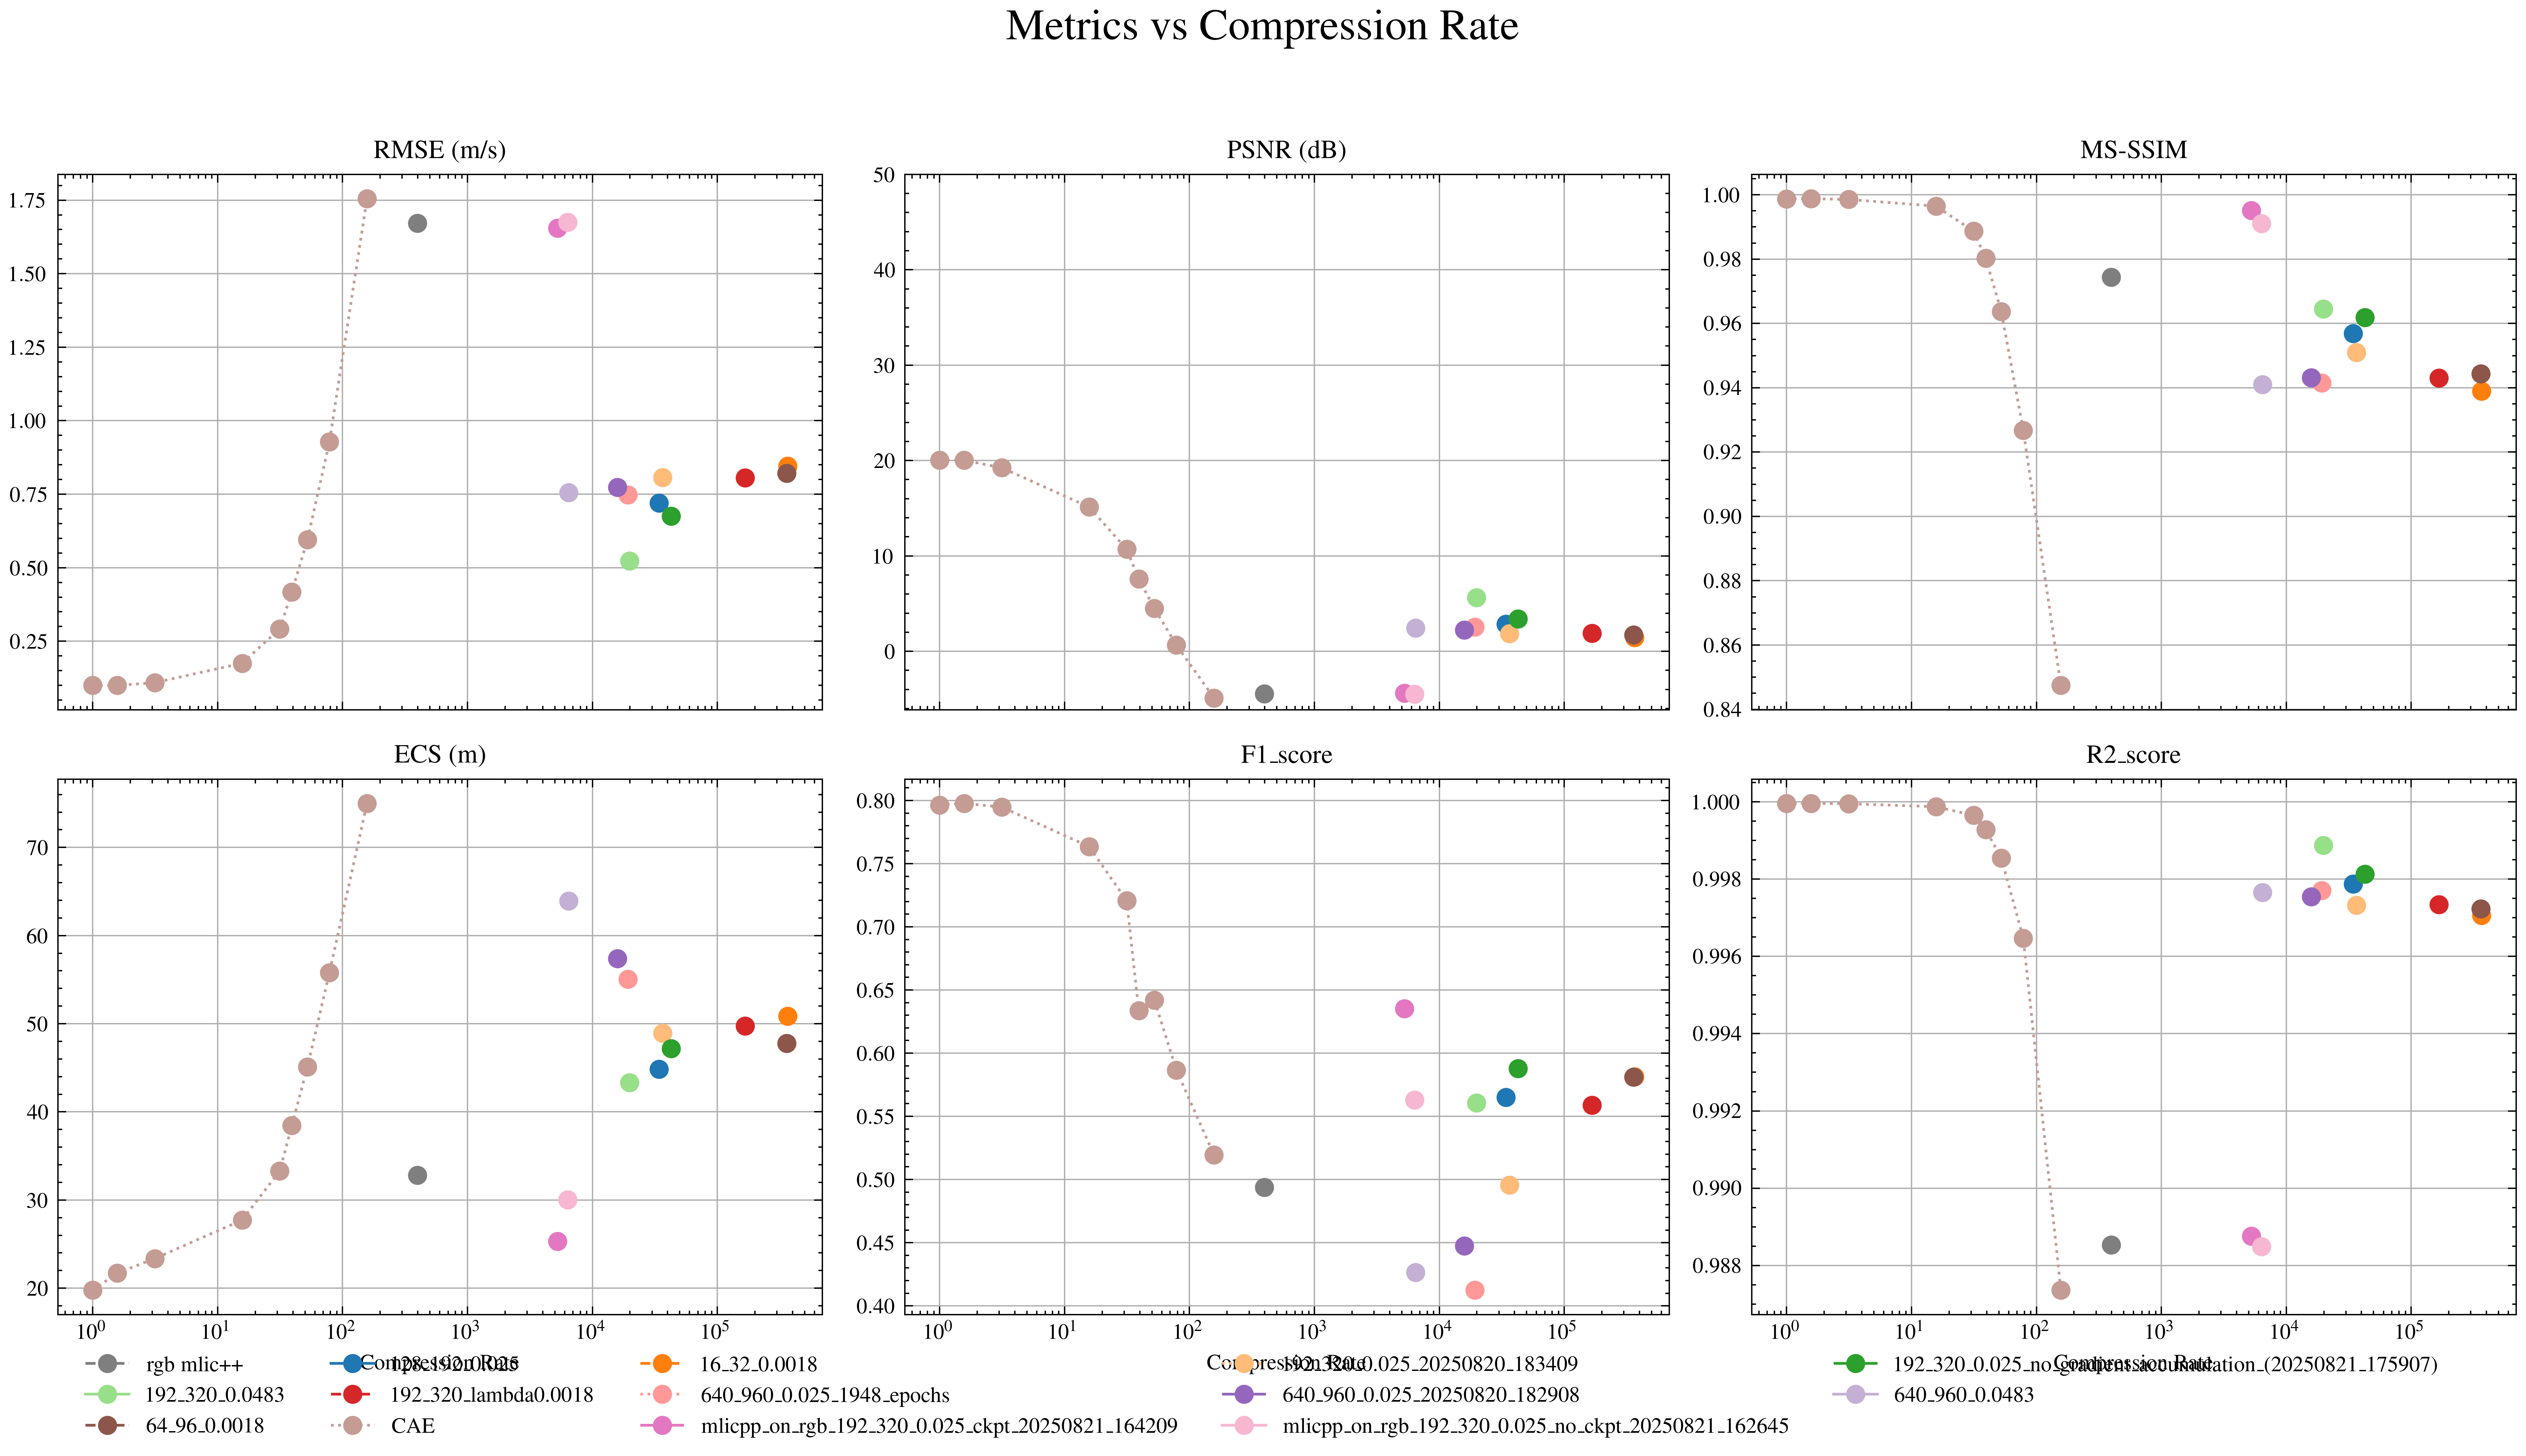

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Use science style
plt.style.use(["science", "ieee"])

# List of metrics with units
metrics = {
    "RMSE": "m/s",
    "PSNR": "dB",
    "MS-SSIM": None,
    "ECS": "m",
    "F1_score": None,
    "R2_score": None
}

n_metrics = len(metrics)
ncols = 3
nrows = int(np.ceil(n_metrics / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows), sharex=True)
axes = axes.flatten()

# Sort models alphabetically for consistent coloring
models = sorted(model_metrics.keys())

# Use a qualitative colormap with enough distinct colors
colors = plt.cm.tab10.colors if len(models) <= 10 else plt.cm.tab20.colors

# Collect handles and labels for the legend
handles, labels = [], []

# Define PCA layers and their numeric identifiers
pca_layer_numbers = [0, 1, 2]  # corresponds to Pool_upsample_0_layers, etc.


# Plot each metric
for idx, (metric, unit) in enumerate(metrics.items()):
    ax = axes[idx]
    filtered_lines = []
    filtered_labels = []

    # x_csv = space_depth_pca_metrics_df["CR"]
    # y_csv = space_depth_pca_metrics_df[metric]
    # csv_line, = ax.plot(
    #     x_csv, y_csv,
    #     label="depth+spatial PCA",
    #     linestyle="--",
    #     marker="o",
    #     color="tab:gray",
    #     linewidth=2
    # )
    
    # if idx == 0:
    #     handles.append(csv_line)
    #     labels.append("depth+spatial PCA")


    # # Plot all seasonal DataFrames from season_dfs
    # for season, df in season_dfs.items():
    #     if metric in df.columns:
    #         ax.plot(
    #             df["CR"], df[metric],
    #             label=f"complete PCA, season {season}",
    #             linestyle="--",
    #             marker="s",
    #             alpha=0.7
    #         )
    #         if idx == 0:
    #             handles.append(ax.lines[-1])
    #             labels.append(f"complete PCA, season {season}")


    # Plot model data
    for i, model in enumerate(models):

        if model =="1600_2400_0.0018":
            continue
        cr_values = sorted(model_metrics[model].keys())
        x = cr_values
        y = [model_metrics[model][cr][metric] for cr in x]
        line, = ax.plot(x, y, label=model, marker='o', color=colors[i % len(colors)])
        if idx == 0:  # Collect legend items only once
            handles.append(line)
            labels.append(model)


        # # --- Add Filtered_F1_score if metric is F1_score ---
        # if metric == "F1_score":
        #     y_filt = [model_metrics[model][cr].get("Filtered_F1_score", np.nan) for cr in x]
        #     filt_line, = ax.plot(
        #         x, y_filt,
        #         label=f"{model} (filtered)",
        #         marker='x',
        #         color=colors[i % len(colors)],
        #         alpha=0.55,
        #         linestyle=':',
        #         markersize=7
        #     )
        #     filtered_lines.append(filt_line)
        #     filtered_labels.append(f"{model} (filtered)")

    # Add PCA data to the plots

    # for pca_model in pca_rmse_dict.keys():

        
    #     cr_values = list(pca_rmse_dict[pca_model].keys())
    #     y_values = [pca_rmse_dict[pca_model][cr][metric] for cr in cr_values]
    #     label = pca_model.replace("_", " ")
    #     line, = ax.plot(cr_values, y_values, label=label, linestyle="--", marker='.')
    #     if idx == 0:
    #         handles.append(line)
    #         labels.append(label)

    ax.set_xscale("log")
    title = f"{metric} ({unit})" if unit else metric
    ax.set_title(title)
    ax.grid(True)
    if metric == "PSNR":
        ax.set_ylim(top=50)
    if idx // ncols == nrows - 1:
        ax.set_xlabel("Compression Rate")

    # Add legend for filtered lines only in F1_score subplot
    if metric == "F1_score" and filtered_lines:
        ax.legend(filtered_lines, filtered_labels, loc="lower left", fontsize=6.5, frameon=True)

# Hide unused subplots (if any)
for j in range(n_metrics, len(axes)):
    fig.delaxes(axes[j])

# sorted_handles_labels = sorted(zip(labels, handles), key=lambda x: x[0])
# sorted_labels, sorted_handles = zip(*sorted_handles_labels)

# Sort and zip handles and labels
#sorted_handles_labels = sorted(zip(labels, handles), key=lambda x: x[0])
sorted_handles_labels = sorted(zip(labels, handles), key=lambda x: custom_label_sort(x[0]))
# Parameters for legend layout
nrow = 2
ncol = 5 #int(np.ceil(len(sorted_handles_labels) / nrow))

#legend_matrix = make_legend_matrix(sorted_handles_labels, nrow, ncol)
# n_total = nrow * ncol

# # Pad the list with dummy entries to fill the matrix if needed
# padded = sorted_handles_labels + [(None, None)] * (n_total - len(sorted_handles_labels))

# # Convert to a NumPy object array and reshape row-wise


# # Flatten row-wise
# rowwise_handles_labels = legend_matrix.flatten()

# # Remove dummy entries (None)
# rowwise_labels = [h for h, l in rowwise_handles_labels if h is not None]
# rowwise_handles = [l for h, l in rowwise_handles_labels if h is not None]

labels  = np.array(sorted_handles_labels)[:,0]
handles = np.array(sorted_handles_labels)[:,1]

handles_reordered = reorder_rowwise(list(handles), ncol)
labels_reordered = reorder_rowwise(list(labels), ncol)


fig.suptitle("Metrics vs Compression Rate", fontsize=16)
fig.tight_layout(rect=[0, 0.12, 1, 0.95])

# Keep the global legend for all curves, sorted by name
fig.legend(
    handles_reordered, 
    labels_reordered, 
    loc='lower center', #ncol=int(np.ceil(len(sorted_handles_labels) / 2)) 
    ncol=ncol,
    bbox_to_anchor=(0.5, -0.02)
)

plt.show()


In [ ]:
# Plot Reconstructed Arrays
plt.figure(figsize=(10, 6))

# Plot ground truth
plt.plot(test_ssp_truth[10, :-1, 10, 10], depth_array[:-1], label="Ground Truth", linestyle="--", color="black")

# Plot reconstructed arrays
for model_name in ['ssp mlic++',  'CAE pooled by factor 8x8']: # , cr_dict in outputs.items():
    cr_dict = outputs[model_name]
    for cr in [19834.10084020844,9768.888888888889]:# in cr_dict.items():
        if cr in cr_dict:
            reconstructed_arr = cr_dict[cr]
        else:
            continue
        # Plot original reconstructed array
        plt.plot(reconstructed_arr[10, :-1, 10, 10], depth_array[:-1], label=f"{model_name} @ CR {int(cr)}")

        # # Apply filtering
        # b, a = butter(N=2, Wn=0.107, btype='low', analog=False)
        # filtered_profile = filtfilt(b, a, reconstructed_arr[10, :-1, 10, 10])

        # # Plot filtered reconstructed array
        # plt.plot(filtered_profile, depth_array[:-1], label=f"Filtered {model_name} @ CR {cr}", linestyle=":")

plt.gca().invert_yaxis()  # Invert y-axis to show depth increasing downward
plt.xlabel("Celerity (m/s)")
plt.ylabel("Depth (m)")
plt.title("Reconstructed Arrays vs Depth")
plt.legend()
plt.grid()
plt.show()

NameError: name 'test_ssp_truth' is not defined

<Figure size 6000x3600 with 0 Axes>

In [ ]:
column_width = 25
metrics = ["RMSE", "PSNR", "MS-SSIM", "ECS", "MAE", "mean_error_n_min_max", "F1_score", "R2_score", "bpp"]

# Pick the highest CR for each model
selected_cr = {}
for name in model_metrics.keys():
    crs = list(model_metrics[name].keys())
    if crs:
        selected_cr[name] = max(crs)
    else:
        selected_cr[name] = None

header = f'{"Metric":{column_width}s} | ' + ' | '.join([f'{name:{column_width}s}' for name in model_metrics.keys()]) + ' |'
print('-' * len(header))
print(header)
print('-' * len(header))

for metric in metrics:
    print(f'{metric:{column_width}s}', end=' | ')
    for name in model_metrics.keys():
        cr = selected_cr[name]
        if cr is None:
            value = float('nan')
        elif metric == "bpp":
            value = model_metrics[name][cr].get("bits_per_element", float('nan'))
        else:
            value = model_metrics[name][cr].get(metric, float('nan'))
        print(f'{value:{column_width}.3f}', end=' | ')
    print()
print('-' * len(header))

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Metric                    | ssp mlic++                | mbt2018-mean              | cheng2020-anchor          | bmshj2018-factorized      | rgb mlic++                | CAE                       | CAE pooled by factor 4x4  | CAE pooled by factor 8x8  |
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
RMSE                      |                     0.805 |                     1.790 |                     1.824 |                     1.949 |                     1.672 |                     1.755 |                     2.680 |                     

# Plot

In [ ]:
# t = 10  # Example: first time step
# lat = 10  # Example: first latitude index
# lon = 10  # Example: first longitude index

# # Create a plot for each model in outputs and add ground truth
# plt.figure(figsize=(8, 10))

# # Plot ground truth
# x_ground_truth = test_ssp_arr[t, :, lat, lon]  # Sound speed profile for ground truth
# y = depth_array  # Depth array
# plt.plot(x_ground_truth, y, label="Ground Truth", linestyle="--", color="black")

# # Plot each model's output
# for model_name, ssp_ae_test_arr in outputs.items():
#     # Extract the profile for the given indices
#     x = ssp_ae_test_arr[t, :-3, lat, lon]  # Sound speed profile for the model

#     # Plot the profile
#     plt.plot(x, y[:-3], label=model_name)

# # Add labels, legend, and grid
# plt.gca().invert_yaxis()  # Invert y-axis to show depth increasing downward
# plt.xlabel("Sound Speed (m/s)")
# plt.ylabel("Depth (m)")
# plt.title("Sound Speed Profiles per Model")
# plt.legend()
# plt.grid()
# plt.show()